In [12]:
import polars as pl
dataset = pl.read_csv('../data/processed/dataset_clean_onehot.csv')


In [46]:
pl.Config.set_tbl_rows(-1)
coocurences = dataset\
    .with_columns(pl.col('StimSite').str.strip_chars_end('_123456789'))\
    .group_by(['Error_type_annot', 'StimSite']).len()\
    .sort(['StimSite', 'len'], descending=True)\
    .filter(pl.col('Error_type_annot') != 'нет')
#    .group_by(['StimSite']).head(4)\

In [44]:
import matplotlib.pyplot as plt


([<matplotlib.axis.YTick at 0x23641023690>,
 [Text(0, 0, 'задержка'),
  Text(0, 1, 'дизартрия'),
  Text(0, 2, 'фонетическая парафазия'),
  Text(0, 3, 'семантическая парафазия'),
  Text(0, 4, 'аномия'),
  Text(0, 5, 'поиск слова'),
  Text(0, 6, 'speech arrest')])

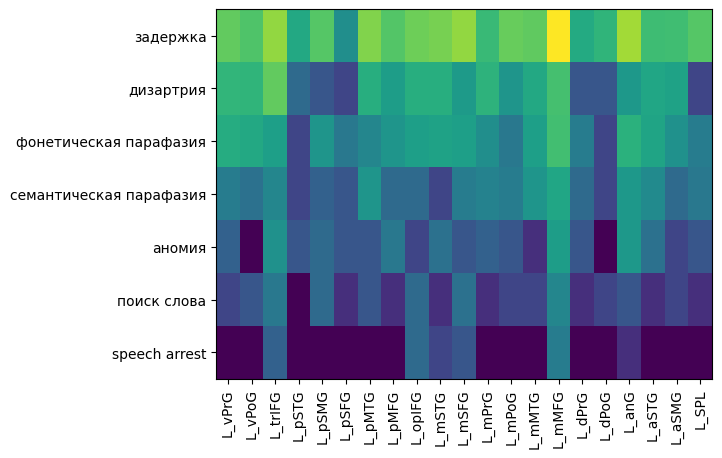

In [64]:
from numpy import log2

pivot = coocurences.pivot(index='Error_type_annot',
                          on='StimSite',
                          values='len')\
                    .fill_null(1)

rows = pivot['Error_type_annot'].to_list()
cols = pivot.columns[1:]

plt.imshow(log2(pivot[:, 1:].to_numpy()), aspect='auto')
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(rows)), rows)
